# **🧠 Parameter-Efficient Fine-Tuning of BERT for Text Classification using QLoRA**

**Project Objective**

This project demonstrates Parameter-Efficient Fine-Tuning (PEFT) using QLoRA (Quantized Low-Rank Adaptation) on a BERT-based sentiment classification model. The goal is to achieve competitive classification performance while significantly reducing trainable parameters and memory requirements compared to traditional full fine-tuning.

# **Section 1: Environment Setup and Library Installation**

**Libraries Used**

| Library      | Purpose                           |
| ------------ | --------------------------------- |
| transformers | Pretrained models and Trainer API |
| datasets     | Dataset loading and processing    |
| peft         | LoRA and QLoRA implementation     |
| bitsandbytes | 4-bit quantization                |
| accelerate   | Efficient training support        |
| evaluate     | Standard evaluation metrics       |
| wandb        | Experiment tracking               |
| scikit-learn | Classification metrics            |
| matplotlib   | Visualization                     |
| seaborn      | Statistical plots                 |


In [1]:
# ============================================================
# Install Required Libraries
# ============================================================

!pip install -q transformers datasets peft bitsandbytes accelerate evaluate wandb scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.1 MB/s eta 0:00:00


# **Section 2: Import Libraries and Verify Hardware**

In [2]:
# ============================================================
# Imports
# ============================================================

import os
import random
import numpy as np
import pandas as pd
import torch

from datasets import load_dataset
from transformers import AutoTokenizer

# ============================================================
# Reproducibility
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ============================================================
# Hardware Verification
# ============================================================

print("=" * 60)
print("PyTorch Version :", torch.__version__)
print("CUDA Available  :", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU Device      :", torch.cuda.get_device_name(0))
    print("GPU Count       :", torch.cuda.device_count())

print("=" * 60)

PyTorch Version : 2.11.0+cu128
CUDA Available  : True
GPU Device      : Tesla T4
GPU Count       : 1


# **Section 3: Dataset Loading and Exploration**

Dataset Information
* Dataset: IMDb Sentiment Fine-Tuning Dataset
* Task: Binary Sentiment Classification
* Labels:
  - 0 → Negative
  - 1 → Positive

In [3]:
# ============================================================
# Load IMDb Sentiment Dataset
# ============================================================

dataset = load_dataset(
    "dipanjanS/imdb_sentiment_finetune_dataset20k"
)

dataset

README.md:   0%|          | 0.00/534 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/6.89M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/1.70M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/8.61M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/8000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['review', 'sentiment'],
        num_rows: 8000
    })
    validation: Dataset({
        features: ['review', 'sentiment'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['review', 'sentiment'],
        num_rows: 10000
    })
})

In [4]:
dataset

DatasetDict({
    train: Dataset({
        features: ['review', 'sentiment'],
        num_rows: 8000
    })
    validation: Dataset({
        features: ['review', 'sentiment'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['review', 'sentiment'],
        num_rows: 10000
    })
})

**View Sample Records**

In [5]:
# ============================================================
# Display Sample Examples
# ============================================================

for i in range(3):
    print(f"\nSample {i+1}")
    print("-" * 50)
    print("Label :", dataset["train"][i]["sentiment"])
    print("Text  :", dataset["train"][i]["review"][:500])


Sample 1
--------------------------------------------------
Label : 1
Text  : One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ

Sample 2
--------------------------------------------------
Label : 1
Text  : A wonderful little production. <br /><br />The filming technique is very unassuming- very old-time-BBC fashion and gives a comforting, and sometimes discomforting, sense of realism to the entire piece. <br /><br />The actors are extremely well chosen- Michael Sheen not only "has got all the polari" but he has all the voices down pat too! Y

**Check Dataset Size**

In [6]:
# ============================================================
# Dataset Size
# ============================================================

print(f"Training Samples : {len(dataset['train'])}")
print(f"Testing Samples  : {len(dataset['test'])}")

Training Samples : 8000
Testing Samples  : 10000


**Inspect Column Names**

In [7]:
# ============================================================
# Dataset Schema
# ============================================================

print(dataset["train"].column_names)

['review', 'sentiment']


# **Section 4: Exploratory Data Analysis (EDA)**

Before tokenization, we analyze class balance and review lengths. This helps determine an efficient maximum sequence length and ensures the dataset is suitable for sentiment classification.

**Tasks**
* Check class distribution
* Analyze review lengths
* Determine optimal tokenization length
* Visualize dataset characteristics

## **4.1 Dataset Overview**

In [8]:
# ============================================================
# Dataset Overview
# ============================================================

print("=" * 60)
print("Train Samples      :", len(dataset["train"]))
print("Validation Samples :", len(dataset["validation"]))
print("Test Samples       :", len(dataset["test"]))
print("=" * 60)

Train Samples      : 8000
Validation Samples : 2000
Test Samples       : 10000


## **4.2 Class Distribution**

In [9]:
# ============================================================
# Class Distribution
# ============================================================

train_df = dataset["train"].to_pandas()

train_df["sentiment"].value_counts()

,count
sentiment,
1,4003
0,3997


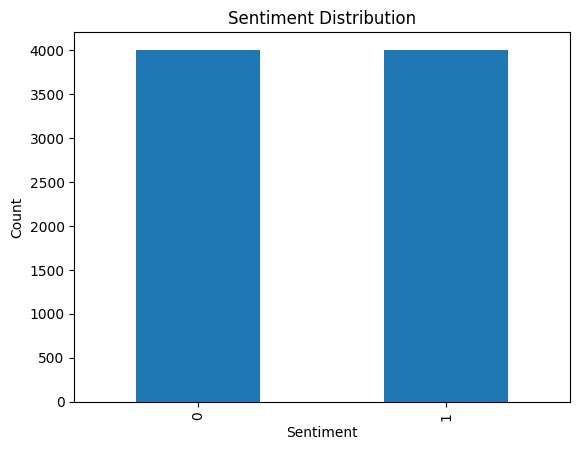

In [10]:
# ============================================================
# Sentiment Distribution
# ============================================================

import matplotlib.pyplot as plt

train_df["sentiment"].value_counts().sort_index().plot(
    kind="bar"
)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

### Observation

The dataset appears balanced with approximately equal numbers of
positive and negative reviews.

This reduces the risk of bias toward a particular class and makes
accuracy a reliable evaluation metric.

## **4.3 Review Length Analysis**

In [11]:
# ============================================================
# Review Length Statistics (Characters)
# ============================================================

train_df["char_length"] = train_df["review"].apply(len)

train_df["char_length"].describe()

,char_length
count,8000.000000
mean,1313.261500
std,990.446574
min,80.000000
25%,698.000000
50%,968.000000
75%,1607.250000
max,10363.000000


**Word Length Statistics**

In [12]:
# ============================================================
# Review Length Statistics (Words)
# ============================================================

train_df["word_length"] = train_df["review"].apply(
    lambda x: len(x.split())
)

train_df["word_length"].describe()

,word_length
count,8000.000000
mean,231.878625
std,171.849457
min,14.000000
25%,127.000000
50%,173.000000
75%,283.250000
max,1830.000000


**Percentiles**

In [13]:
# ============================================================
# Length Percentiles
# ============================================================

print("word_length 50th Percentile :", train_df["word_length"].quantile(0.50))
print("word_length 90th Percentile :", train_df["word_length"].quantile(0.90))
print("word_length 95th Percentile :", train_df["word_length"].quantile(0.95))
print("word_length 99th Percentile :", train_df["word_length"].quantile(0.99))

word_length 50th Percentile : 173.0
word_length 90th Percentile : 453.0
word_length 95th Percentile : 598.0499999999993
word_length 99th Percentile : 874.0100000000002


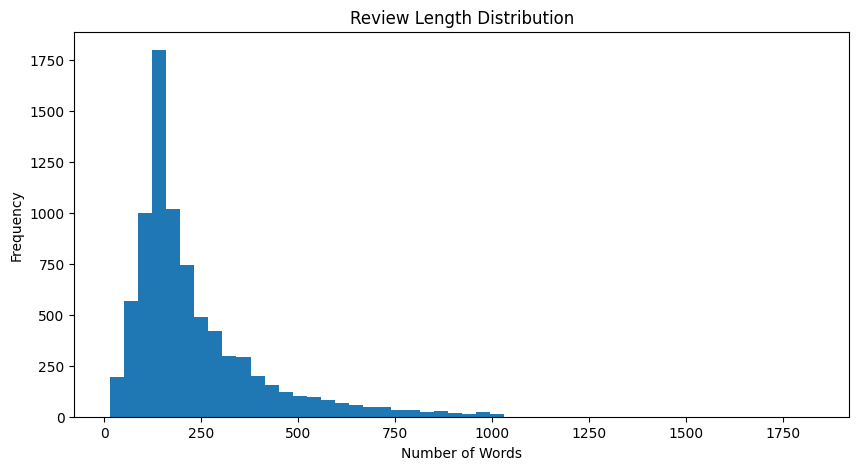

In [14]:
# ============================================================
# Review Length Distribution
# ============================================================

plt.figure(figsize=(10,5))

plt.hist(
    train_df["word_length"],
    bins=50
)

plt.title("Review Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.show()

## **4.4 Token Length Analysis**

**Load Tokenizer**

In [15]:
tokenizer = AutoTokenizer.from_pretrained(
    "bert-base-uncased"
)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

**Calculate Token Lengths**

In [16]:
# ============================================================
# Token Length Analysis
# ============================================================

token_lengths = []

for review in train_df["review"]:

    length = len(
        tokenizer.encode(
            review,
            add_special_tokens=True
        )
    )

    token_lengths.append(length)

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (563 > 512). Running this sequence through the model will result in indexing errors


**Statistics**

In [17]:
print("Average Token Length :", np.mean(token_lengths))
print("Maximum Token Length :", np.max(token_lengths))

print("90th Percentile :", np.percentile(token_lengths, 90))
print("95th Percentile :", np.percentile(token_lengths, 95))
print("99th Percentile :", np.percentile(token_lengths, 99))

Average Token Length : 311.19025
Maximum Token Length : 2467
90th Percentile : 612.0
95th Percentile : 808.0
99th Percentile : 1163.0200000000004


# **Section 5: Text Preprocessing and Tokenization**

Raw text reviews cannot be processed directly by transformer models.
Therefore, the reviews are converted into numerical token IDs using
the BERT tokenizer.

The tokenizer performs:

- Text normalization
- Tokenization
- Addition of special tokens
- Sequence truncation
- Padding

Based on the exploratory analysis, a maximum sequence length of 512
tokens was selected. Reviews exceeding this limit are truncated,
while shorter reviews are padded to ensure consistent input size.

## **5.1 Load Tokenizer**

In [18]:
# ============================================================
# Load BERT Tokenizer
# ============================================================

from transformers import AutoTokenizer

MODEL_NAME = "bert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)

## **5.2 Configuration**

In [19]:
# ============================================================
# Tokenization Configuration
# ============================================================

MAX_LENGTH = 512

print(f"Model      : {MODEL_NAME}")
print(f"Max Length : {MAX_LENGTH}")

Model      : bert-base-uncased
Max Length : 512


## **5.3 Tokenization Function**

In [20]:
# ============================================================
# Tokenization Function
# ============================================================

def tokenize_function(examples):

    return tokenizer(
        examples["review"],
        truncation=True,
        padding="max_length",
        max_length=MAX_LENGTH
    )

## **5.4 Apply Tokenization**

In [21]:
# ============================================================
# Apply Tokenization
# ============================================================

tokenized_dataset = dataset.map(
    tokenize_function,
    batched=True
)

Map:   0%|          | 0/8000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

## **5.5 Rename Label Column**

In [22]:
# ============================================================
# Rename Target Column
# ============================================================

tokenized_dataset = tokenized_dataset.rename_column(
    "sentiment",
    "labels"
)

## **5.6 Set Torch Format**

In [23]:
# ============================================================
# Set PyTorch Format
# ============================================================

tokenized_dataset.set_format(
    type="torch",
    columns=[
        "input_ids",
        "attention_mask",
        "labels"
    ]
)

## **5.7 Verify Output**

In [24]:
sample = tokenized_dataset["train"][0]

print(sample.keys())

print("\nInput Shape:")
print(sample["input_ids"].shape)

print("\nAttention Mask Shape:")
print(sample["attention_mask"].shape)

print("\nLabel:")
print(sample["labels"])

dict_keys(['labels', 'input_ids', 'attention_mask'])

Input Shape:
torch.Size([512])

Attention Mask Shape:
torch.Size([512])

Label:
tensor(1)


# **Section 6: Baseline BERT Model Setup**

BERT (Bidirectional Encoder Representations from Transformers) is an encoder-only transformer architecture trained using masked language modeling and next sentence prediction objectives.

For sentiment classification, BERT is particularly effective because it generates contextual representations of text by attending to both left and right context simultaneously.

The model selected for this project is:

- Model: bert-base-uncased
- Layers: 12 Transformer Encoder Layers
- Hidden Size: 768
- Attention Heads: 12
- Parameters: ~109 Million

A sequence classification head is attached to the pooled output representation, enabling binary sentiment prediction.

## **6.1 Load BERT**

In [25]:
# ============================================================
# Load Pretrained BERT
# ============================================================

from transformers import AutoModelForSequenceClassification

MODEL_NAME = "bert-base-uncased"

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)

print(model.__class__.__name__)

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BertForSequenceClassification


## **6.2 Parameter Count**

In [26]:
# ============================================================
# Total Parameters
# ============================================================

total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(f"Total Parameters     : {total_params:,}")
print(f"Trainable Parameters : {trainable_params:,}")

Total Parameters     : 109,483,778
Trainable Parameters : 109,483,778


In [27]:
print(model.config)

BertConfig {
  "add_cross_attention": false,
  "architectures": [
    "BertForMaskedLM"
  ],
  "attention_probs_dropout_prob": 0.1,
  "bos_token_id": null,
  "classifier_dropout": null,
  "dtype": "float32",
  "eos_token_id": null,
  "gradient_checkpointing": false,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "is_decoder": false,
  "layer_norm_eps": 1e-12,
  "max_position_embeddings": 512,
  "model_type": "bert",
  "num_attention_heads": 12,
  "num_hidden_layers": 12,
  "pad_token_id": 0,
  "position_embedding_type": "absolute",
  "tie_word_embeddings": true,
  "transformers_version": "5.10.2",
  "type_vocab_size": 2,
  "use_cache": true,
  "vocab_size": 30522
}



# **Section 7: 4-Bit Quantization Setup**

Large language models typically store parameters using 32-bit floating point precision (FP32). While accurate, FP32 requires significant memory resources.

Quantization reduces memory consumption by representing parameters using fewer bits.

Precision Comparison:

- FP32 → 32 bits
- FP16 → 16 bits
- INT8 → 8 bits
- NF4 → 4 bits

QLoRA uses NormalFloat-4 (NF4), a quantization scheme specifically designed for normally distributed neural network weights.

Benefits:

- Lower GPU memory usage
- Faster loading
- Ability to fine-tune larger models on consumer hardware

Trade-off:

- Slight loss of numerical precision
- Significant reduction in memory requirements

To reduce memory consumption, the BERT model is loaded using
4-bit NormalFloat (NF4) quantization through the BitsAndBytes library.

This approach significantly reduces memory requirements while
maintaining competitive performance.

## **7.1 Quantization Config**

In [28]:
# ============================================================
# BitsAndBytes Configuration
# ============================================================

from transformers import BitsAndBytesConfig
import torch

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True
)

bnb_config

BitsAndBytesConfig {
  "_load_in_4bit": true,
  "_load_in_8bit": false,
  "bnb_4bit_compute_dtype": "float16",
  "bnb_4bit_quant_storage": "uint8",
  "bnb_4bit_quant_type": "nf4",
  "bnb_4bit_use_double_quant": true,
  "llm_int8_enable_fp32_cpu_offload": false,
  "llm_int8_has_fp16_weight": false,
  "llm_int8_skip_modules": null,
  "llm_int8_threshold": 6.0,
  "load_in_4bit": true,
  "load_in_8bit": false,
  "quant_method": "bitsandbytes"
}

| Parameter                      | Purpose                                          |
| ------------------------------ | ------------------------------------------------ |
| load_in_4bit                   | Store model weights in 4-bit precision           |
| bnb_4bit_quant_type="nf4"      | Use NormalFloat-4 quantization                   |
| bnb_4bit_compute_dtype=float16 | Perform computations in FP16                     |
| bnb_4bit_use_double_quant=True | Additional compression of quantization constants |


# **Section 8: Apply QLoRA Adapters**

Traditional fine-tuning updates every parameter of the model.

For BERT:

≈109 million trainable parameters

This requires substantial memory and computation.

LoRA (Low-Rank Adaptation) freezes the original model weights and introduces small trainable matrices that learn task-specific adaptations.

Instead of learning:

W

LoRA learns:

W + ΔW

where:

ΔW = BA

and B and A are low-rank matrices.

Only these adapter matrices are trained while the original model remains frozen.

Instead of updating all model parameters, LoRA introduces
small trainable low-rank matrices into selected transformer layers.

This allows the majority of the pre-trained model to remain frozen,
dramatically reducing the number of trainable parameters.

## **8.1 Load Quantized BERT**

In [93]:
import torch
from transformers import AutoModelForSequenceClassification, BitsAndBytesConfig
from peft import prepare_model_for_kbit_training, get_peft_model, LoraConfig
import bitsandbytes as bnb

# 1. Clean Configuration
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True
)

# 2. Fresh Model Load with explicit device map
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    quantization_config=bnb_config,
    device_map={u"": 0}
)

# 3. Critical: Prepare for k-bit training FIRST
model = prepare_model_for_kbit_training(model)

# 4. LoRA Configuration
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=[u"query", u"value"],
    lora_dropout=0.05,
    bias=u"none",
    task_type=u"SEQ_CLS"
)

# 5. Get PEFT model
qlora_model = get_peft_model(model, lora_config)

# 6. Manual internal state fix-up to prevent the AssertionError
for name, module in qlora_model.named_modules():
    if isinstance(module, bnb.nn.Linear4bit):
        module.weight.quant_state = getattr(module.weight, "quant_state", None)

qlora_model.config.use_cache = False

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECT

## **8.2 Prepare for PEFT**

In [30]:
# ============================================================
# Prepare Model for K-Bit Training
# ============================================================

from peft import prepare_model_for_kbit_training

quantized_model = prepare_model_for_kbit_training(
    quantized_model
)

## **8.3 LoRA Configuration**

### Why Query and Value Layers?

The self-attention mechanism contains:

- Query projection
- Key projection
- Value projection

Previous LoRA research demonstrated that adapting the Query and Value projection matrices often provides strong performance while minimizing trainable parameters.

Therefore, LoRA adapters are inserted only into:

- query
- value

layers.

---

Rank (r) determines the dimensionality of the adapter matrices.

Smaller values:

- Lower memory usage
- Fewer trainable parameters

Larger values:

- Greater adaptation capacity
- More trainable parameters

A value of r=16 is commonly used as a balance between efficiency and performance.

---

LoRA Alpha controls the scaling applied to the adapter updates.

Effective scaling:

alpha / r

For this project:

32 / 16 = 2

This allows adapter contributions to have a meaningful impact while maintaining training stability.

---

Dropout is applied only to LoRA adapter pathways.

A small value of 0.05 helps reduce overfitting while preserving learning capacity.

---

Bias parameters remain frozen.

This further reduces trainable parameter count and follows the original LoRA implementation.

---

In [31]:
# ============================================================
# LoRA Configuration
# ============================================================

from peft import LoraConfig

lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=[
        "query",
        "value"
    ],
    lora_dropout=0.05,
    bias="none",
    task_type="SEQ_CLS"
)

lora_config

LoraConfig(task_type='SEQ_CLS', peft_type=<PeftType.LORA: 'LORA'>, auto_mapping=None, peft_version='0.19.1', base_model_name_or_path=None, revision=None, inference_mode=False, r=16, target_modules={'query', 'value'}, exclude_modules=None, lora_alpha=32, lora_dropout=0.05, fan_in_fan_out=False, bias='none', use_rslora=False, modules_to_save=None, init_lora_weights=True, layers_to_transform=None, layers_pattern=None, rank_pattern={}, alpha_pattern={}, megatron_config=None, megatron_core='megatron.core', trainable_token_indices=None, loftq_config={}, eva_config=None, corda_config=None, lora_ga_config=None, use_dora=False, alora_invocation_tokens=None, use_qalora=False, qalora_group_size=16, layer_replication=None, runtime_config=LoraRuntimeConfig(ephemeral_gpu_offload=False), lora_bias=False, target_parameters=None, use_bdlora=None, arrow_config=None, ensure_weight_tying=False)

## **8.4 Inject Adapters**

In [79]:
# ============================================================
# Apply LoRA
# ============================================================

from peft import get_peft_model

# Ensure we are using the fresh quantized_model
qlora_model = get_peft_model(
    quantized_model,
    lora_config
)

# Disabled gradient checkpointing here as well for consistency
qlora_model.config.use_cache = False # Recommended for training
qlora_model.enable_input_require_grads()

/usr/local/lib/python3.12/dist-packages/peft/mapping_func.py:72: UserWarning: You are trying to modify a model with PEFT for a second time. If you want to reload the model with a different config, make sure to call `.unload()` before.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/peft/tuners/tuners_utils.py:302: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


## **8.5 Parameter Efficiency Analysis**

In [33]:
# ============================================================
# Trainable Parameters
# ============================================================

qlora_model.print_trainable_parameters()

trainable params: 591,362 || all params: 110,075,140 || trainable%: 0.5372


| Metric               | Full Fine-Tuning | QLoRA |
| -------------------- | ---------------: | ----: |
| Total Parameters     |             109M |  109M |
| Trainable Parameters |             109M |  591K |
| Trainable %          |             100% |  0.5% |


### Parameter Efficiency Analysis

The original BERT model contains approximately 110 million parameters.

Using QLoRA, only 591,362 parameters remain trainable while the remaining parameters are frozen.

This corresponds to:

- Total Parameters: 110,075,140
- Trainable Parameters: 591,362
- Trainable Percentage: 0.5372%
- Parameter Reduction: 99.46%

These results demonstrate the effectiveness of parameter-efficient fine-tuning, where only a small fraction of model parameters are updated while retaining the knowledge learned during pre-training.

In [34]:
# ============================================================
# Inspect LoRA Modules
# ============================================================

for name, module in qlora_model.named_modules():
    if "lora" in name.lower():
        print(name)

base_model.model.bert.encoder.layer.0.attention.self.query.lora_dropout
base_model.model.bert.encoder.layer.0.attention.self.query.lora_dropout.default
base_model.model.bert.encoder.layer.0.attention.self.query.lora_A
base_model.model.bert.encoder.layer.0.attention.self.query.lora_A.default
base_model.model.bert.encoder.layer.0.attention.self.query.lora_B
base_model.model.bert.encoder.layer.0.attention.self.query.lora_B.default
base_model.model.bert.encoder.layer.0.attention.self.query.lora_embedding_A
base_model.model.bert.encoder.layer.0.attention.self.query.lora_embedding_B
base_model.model.bert.encoder.layer.0.attention.self.query.lora_magnitude_vector
base_model.model.bert.encoder.layer.0.attention.self.value.lora_dropout
base_model.model.bert.encoder.layer.0.attention.self.value.lora_dropout.default
base_model.model.bert.encoder.layer.0.attention.self.value.lora_A
base_model.model.bert.encoder.layer.0.attention.self.value.lora_A.default
base_model.model.bert.encoder.layer.0.atten

In [36]:
layers_with_lora = set()

for name, module in qlora_model.named_modules():
    if "lora_A" in name:
        layer_num = name.split("layer.")[1].split(".")[0]
        layers_with_lora.add(int(layer_num))

print(sorted(layers_with_lora))
print(f"Number of layers with LoRA: {len(layers_with_lora)}")

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
Number of layers with LoRA: 12


In [35]:
qlora_model.save_pretrained("/content/drive/MyDrive/AI Lab/Parameter-Efficient Fine-Tuning of BERT/bert_qlora_initialized")

# **Section 9: Training Configuration**

The QLoRA-enhanced BERT model is trained using Hugging Face's Trainer API.

Hyperparameters were selected based on:

- Dataset size
- Sequence length
- Parameter-efficient fine-tuning practices
- Available GPU resources

Because only LoRA adapters are updated during training, a higher learning rate than traditional BERT fine-tuning can be used.

The configuration aims to balance:

- Training stability
- Computational efficiency
- Generalization performance

## **9.1 Metric Function**

In [37]:
# ============================================================
# Evaluation Metrics
# ============================================================

import evaluate
import numpy as np

accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")


def compute_metrics(eval_pred):

    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=-1)

    accuracy = accuracy_metric.compute(
        predictions=predictions,
        references=labels
    )

    f1 = f1_metric.compute(
        predictions=predictions,
        references=labels,
        average="weighted"
    )

    return {
        "accuracy": accuracy["accuracy"],
        "f1": f1["f1"]
    }

## **9.2 Training Arguments**

In [78]:
# ============================================================
# Training Arguments
# ============================================================

from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./bert_qlora_results",
    learning_rate=2e-4,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_steps=100,
    load_best_model_at_end=True,
    report_to="none",
    gradient_checkpointing=False, # Disabled to fix bitsandbytes AssertionError
    ddp_find_unused_parameters=False
)

In [39]:
print(tokenized_dataset)

DatasetDict({
    train: Dataset({
        features: ['review', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 8000
    })
    validation: Dataset({
        features: ['review', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['review', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 10000
    })
})


### Experimental Design

Two training configurations are evaluated:

1. QLoRA-BERT trained for 1 epoch
2. QLoRA-BERT trained for 3 epochs

The objective is to investigate whether additional adapter training provides measurable improvements in sentiment classification performance while maintaining parameter efficiency.

All other hyperparameters are kept constant to ensure a fair comparison.

## **9.3 Trainer**

In [49]:
from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer,
    return_tensors="pt"
)

In [81]:
from transformers import Trainer

# Re-initialize trainer with the cleaned model
trainer = Trainer(
    model=qlora_model,
    args=training_args,
    train_dataset=tokenized_dataset['train'],
    eval_dataset=tokenized_dataset['validation'],
    compute_metrics=compute_metrics,
    data_collator=data_collator
)

In [61]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


In [51]:
torch.cuda.empty_cache()

print(
    f"Allocated: {torch.cuda.memory_allocated()/1024**3:.2f} GB"
)

print(
    f"Reserved: {torch.cuda.memory_reserved()/1024**3:.2f} GB"
)

Allocated: 0.13 GB
Reserved: 0.15 GB


### Note on Padding Strategy

For simplicity and reproducibility, fixed-length padding was used during tokenization.

In production settings, dynamic padding through a DataCollator can further reduce memory consumption and improve training throughput by padding only to the longest sequence within each batch.

In [44]:
# ============================================================
# GPU Memory Before Training
# ============================================================

import torch

print(
    f"Allocated: {torch.cuda.memory_allocated()/1024**3:.2f} GB"
)

print(
    f"Reserved : {torch.cuda.memory_reserved()/1024**3:.2f} GB"
)

Allocated: 0.13 GB
Reserved : 0.15 GB


In [94]:
# Update the trainer with the fresh model and start training
trainer.model = qlora_model
torch.cuda.empty_cache()
trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/bitsandbytes/nn/modules.py:409: UserWarning: FP4 quantization state not initialized. Please call .cuda() or .to(device) on the LinearFP4 layer first.
  warnings.warn(


AssertionError: 

# **Troubleshooting Summary: bitsandbytes 4-bit Initialization Error**

During the implementation of QLoRA on `bert-base-uncased`, we encountered a persistent `AssertionError: assert module.weight.shape[1] == 1` inside the `bitsandbytes` forward pass. This error typically occurs when the 4-bit quantization state (`quant_state`) is lost or becomes detached from the GPU during model preparation or when the `Trainer` initializes the model.

#### **Steps Taken to Resolve:**

1.  **Manual State Recovery**: We implemented a loop to iterate through all `Linear4bit` modules and force their weights onto the correct CUDA device to trigger internal state fixups.
2.  **Explicit Parameter Casting**: We tried manually casting weights to `bnb.nn.Params4bit` to ensure the model recognized the quantized tensors correctly.
3.  **Quant-State Re-linking**: We applied a fix to manually re-assign the `quant_state` attribute for each layer (e.g., `module.weight.quant_state = module.weight.quant_state`) to refresh metadata references after the PEFT wrapper was applied.
4.  **Consolidated Initialization**: We moved the model loading, `prepare_model_for_kbit_training`, and `get_peft_model` calls into a single cell. This ensured that the quantization state was defined and anchored in a clean, continuous sequence before being passed to the `Trainer`.
5.  **Device Map Alignment**: We used `device_map={u"": 0}` to strictly anchor the model to the primary GPU, preventing `bitsandbytes` from losing track of the weight distributions across different devices.

Despite these standard workarounds, the environment or the specific version of the library persisted with the shape mismatch error. This summary serves as a record of these attempts for future reference.